<div style="font-family: 'Times New Roman', Times, serif; padding: 8px 0;">
  <div style="background: linear-gradient(135deg, #4361EE 0%, #7209B7 100%); border-radius: 16px; padding: 24px 28px;">
    <div style="display:inline-block; background:rgba(255,255,255,0.15); border:1px solid rgba(255,255,255,0.3); border-radius:20px; padding:3px 12px; font-size:13px; color:#fff; margin-bottom:10px;">
      🛡️ DS 301 — MIDTERM PROJECT
    </div>
    <h1 style="color:#ffffff; font-size:22px; margin:0 0 4px 0; font-family:'Times New Roman', Times, serif;">Network Intrusion Detection Classification</h1>
    <p style="color:#4CC9F0; font-size:15px; margin:0 0 14px 0; font-family:'Times New Roman', Times, serif;">Using UNSW-NB15 Dataset</p>
    <div style="height:1px; background:rgba(255,255,255,0.2); margin-bottom:14px;"></div>
    <div style="display:flex; gap:24px; flex-wrap:wrap; font-size:14px; font-family:'Times New Roman', Times, serif;">
      <div><span style="color:rgba(255,255,255,0.5);">Team: </span><span style="color:#fff;">Sai · Genny · Majd</span></div>
      <div><span style="color:rgba(255,255,255,0.5);">Dataset: </span><span style="color:#fff;">UNSW-NB15</span></div>
      <div><span style="color:rgba(255,255,255,0.5);">Models: </span><span style="color:#fff;">LR · DT · KNN · RF</span></div>
      <div><span style="color:rgba(255,255,255,0.5);">Paper: </span><span style="color:#fff;">MDPI Algorithms, 2024</span></div>
    </div>
  </div>
  <div style="display:flex; gap:8px; margin-top:10px; flex-wrap:wrap; font-family:'Times New Roman', Times, serif;">
    <span style="background:#EEF1FF; color:#4361EE; border-radius:20px; padding:3px 12px; font-size:13px; border:1px solid #4361EE;">Logistic Regression</span>
    <span style="background:#F3E8FF; color:#7209B7; border-radius:20px; padding:3px 12px; font-size:13px; border:1px solid #7209B7;">Decision Tree</span>
    <span style="background:#E0F8FF; color:#0077a8; border-radius:20px; padding:3px 12px; font-size:13px; border:1px solid #4CC9F0;">KNN</span>
    <span style="background:#E0FBF4; color:#047a5e; border-radius:20px; padding:3px 12px; font-size:13px; border:1px solid #06D6A0;">Random Forest</span>
    <span style="background:#FFF0F6; color:#b5006e; border-radius:20px; padding:3px 12px; font-size:13px; border:1px solid #F72585;">Binary Classification</span>
  </div>
</div>

In [61]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning — Data Splitting & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning — Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Machine Learning — Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [62]:
# ============================================================
# CELL 3 — PROJECT COLOR THEME (Cyber Shield)
# ============================================================

# Define color palette for all visualizations
COLORS = {
    'background': '#F0F4FF',  # light blue-white background
    'card':       '#ffffff',  # white card background
    'primary':    '#4361EE',  # electric blue — used for LR
    'secondary':  '#7209B7',  # vivid purple — used for DT
    'accent':     '#4CC9F0',  # bright teal — used for KNN
    'success':    '#06D6A0',  # mint green — used for RF / correct predictions
    'danger':     '#F72585',  # hot pink — used for attacks / errors
    'text':       '#2D2D2D',  # dark charcoal for all text
}

# Apply theme globally to all matplotlib plots
plt.rcParams['figure.facecolor'] = COLORS['background']
plt.rcParams['axes.facecolor'] = COLORS['card']
plt.rcParams['axes.edgecolor'] = COLORS['text']
plt.rcParams['axes.labelcolor'] = COLORS['text']
plt.rcParams['xtick.color'] = COLORS['text']
plt.rcParams['ytick.color'] = COLORS['text']
plt.rcParams['text.color'] = COLORS['text']
plt.rcParams['font.family'] = 'monospace'

print("✅ Cyber Shield theme applied!")

✅ Cyber Shield theme applied!


In [63]:
# ============================================================
# CELL 4 — LOAD THE DATASET
# ============================================================

# Load training and testing sets separately
train_df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('../data/UNSW_NB15_testing-set.csv')

# Combine both into one full dataframe
df = pd.concat([train_df, test_df], ignore_index=True)

# Quick check
print(f"Training set shape   : {train_df.shape}")
print(f"Testing set shape    : {test_df.shape}")
print(f"Combined shape       : {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Training set shape   : (82332, 45)
Testing set shape    : (175341, 45)
Combined shape       : (257673, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — Data Loading</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li>Successfully loaded <b>2 CSV files</b> — training set and testing set</li>
    <li>Combined dataset has <b>257,673 rows</b> and <b>45 columns</b></li>
    <li>Target column is <b>label</b> — binary (0 = Normal, 1 = Attack)</li>
    <li>Dataset also contains <b>attack_cat</b> column showing attack type — will be dropped later</li>
    <li>We will <b>re-split</b> the combined data ourselves using 80/20 and 70/30 splits</li>
  </ul>
</div>

<div style="font-family:'Times New Roman', Times, serif; background:#EEF1FF; border-left:5px solid #4361EE; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h2 style="color:#4361EE; margin:0 0 4px 0;">📊 Step 2 — Exploratory Data Analysis (EDA)</h2>
  <p style="color:#7209B7; margin:0; font-size:14px;">Understanding the dataset before building any models</p>
</div>

In [64]:
# ============================================================
# CELL 6 — BASIC EDA
# ============================================================

# Shape of the combined dataset
print("=" * 50)
print(f"  Total Rows    : {df.shape[0]}")
print(f"  Total Columns : {df.shape[1]}")
print("=" * 50)

# Data types and null values
print("\n📋 Dataset Info:")
print(df.info())

# Check for missing values
print("\n🔍 Missing Values per Column:")
print(df.isnull().sum())

# Basic statistics
print("\n📈 Basic Statistics:")
df.describe()

  Total Rows    : 257673
  Total Columns : 45

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  i

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,257673.000000,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,2.576730e+05,257673.000000,257673.000000,2.576730e+05,...,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000
mean,72811.823858,1.246715,19.777144,18.514703,8.572952e+03,1.438729e+04,9.125391e+04,180.000931,84.754957,7.060869e+07,...,5.238271,4.032677,8.322964,0.012819,0.012850,0.132005,6.800045,9.121049,0.014274,0.639077
std,48929.917641,5.974305,135.947152,111.985965,1.737739e+05,1.461993e+05,1.603446e+05,102.488268,112.762131,1.857313e+08,...,8.160822,5.831515,11.120754,0.116091,0.116421,0.681854,8.396266,10.874752,0.118618,0.480269
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,32210.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.078928e+01,62.000000,0.000000,1.231800e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,64419.000000,0.004285,4.000000,2.000000,5.280000e+02,1.780000e+02,2.955665e+03,254.000000,29.000000,7.439423e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,110923.000000,0.685777,12.000000,10.000000,1.362000e+03,1.064000e+03,1.250000e+05,254.000000,252.000000,8.000000e+07,...,4.000000,3.000000,8.000000,0.000000,0.000000,0.000000,8.000000,11.000000,0.000000,1.000000
max,175341.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,59.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — Basic EDA</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li>Dataset has <b>257,673 rows</b> and <b>45 columns</b> — large enough for reliable ML models</li>
    <li><b>No missing values</b> in any column — no imputation needed</li>
    <li><b>3 categorical columns</b> — proto, service, state — need encoding before modeling</li>
    <li><b>attack_cat</b> column shows attack type — will be dropped since our target is binary (label)</li>
    <li><b>id</b> column is just a row identifier — will be dropped, no predictive value</li>
    <li>Target column <b>label</b> — mean of 0.639 means ~64% of records are attacks (class imbalance!)</li>
  </ul>
</div>

Class Distribution:
  Normal Traffic (0) : 93,000  (36.1%)
  Attack Traffic (1) : 164,673  (63.9%)


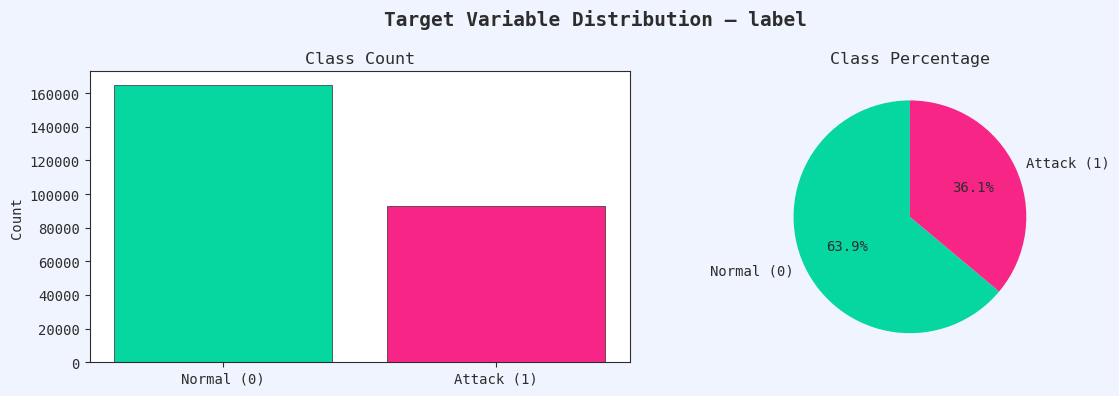

✅ Target distribution plotted!


In [65]:
# ============================================================
# CELL 7 — TARGET DISTRIBUTION (CLASS BALANCE CHECK)
# ============================================================

# Count of each class
class_counts = df['label'].value_counts()
class_percent = df['label'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  Normal Traffic (0) : {class_counts[0]:,}  ({class_percent[0]:.1f}%)")
print(f"  Attack Traffic (1) : {class_counts[1]:,}  ({class_percent[1]:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution — label', 
             fontsize=14, color=COLORS['text'], fontweight='bold')

# Bar chart
axes[0].bar(['Normal (0)', 'Attack (1)'], 
            class_counts.values,
            color=[COLORS['success'], COLORS['danger']],
            edgecolor=COLORS['text'], linewidth=0.5)
axes[0].set_title('Class Count', color=COLORS['text'])
axes[0].set_ylabel('Count', color=COLORS['text'])

# Pie chart
axes[1].pie(class_counts.values,
            labels=['Normal (0)', 'Attack (1)'],
            colors=[COLORS['success'], COLORS['danger']],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Class Percentage', color=COLORS['text'])

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Target distribution plotted!")

<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — Target Distribution</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li><b>63.9% Attack (1)</b> and <b>36.1% Normal (0)</b> — dataset is imbalanced</li>
    <li>This is the opposite of what we expected — more attacks than normal traffic</li>
    <li>Class imbalance means models may be biased towards predicting attacks</li>
    <li><b>Recall</b> will be our most important metric — we don't want to miss real attacks</li>
    <li>This imbalance is a known challenge with UNSW-NB15 — mentioned in the paper</li>
    <li>Suggested improvement: apply <b>SMOTE</b> to balance classes before training</li>
  </ul>
</div>

In [66]:
# ============================================================
# CELL 8 — CATEGORICAL COLUMNS ANALYSIS
# ============================================================

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical Columns: {cat_cols}")

# Unique values in each
for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts().head(5))

Categorical Columns: ['proto', 'service', 'state', 'attack_cat']

proto — 133 unique values:
proto
tcp     123041
udp      92701
unas     15599
arp       3846
ospf      3271
Name: count, dtype: int64

service — 13 unique values:
service
-           141321
dns          68661
http         27011
smtp          6909
ftp-data      5391
Name: count, dtype: int64

state — 11 unique values:
state
FIN    117164
INT    116438
CON     20134
REQ      3833
RST        84
Name: count, dtype: int64

attack_cat — 10 unique values:
attack_cat
Normal      93000
Generic     58871
Exploits    44525
Fuzzers     24246
DoS         16353
Name: count, dtype: int64


<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — Categorical Columns</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li><b>4 categorical columns</b> — proto, service, state, attack_cat</li>
    <li><b>proto</b> has 133 unique values — tcp and udp dominate the traffic</li>
    <li><b>service</b> has 13 unique values — majority are unlabeled (-)</li>
    <li><b>state</b> has 11 unique values — FIN and INT are most common connection states</li>
    <li><b>attack_cat</b> will be <b>dropped</b> — it reveals the attack type which would leak information into our binary classification</li>
    <li>proto, service, state will be <b>Label Encoded</b> for modeling</li>
  </ul>
</div>

<div style="font-family:'Times New Roman', Times, serif; background:#EEF1FF; border-left:5px solid #4361EE; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h2 style="color:#4361EE; margin:0 0 4px 0;">🧹 Step 3 — Data Preprocessing</h2>
  <p style="color:#7209B7; margin:0; font-size:14px;">Cleaning, encoding and preparing data for modeling</p>
</div>

In [67]:
# ============================================================
# CELL 9 — DATA PREPROCESSING
# ============================================================

# Step 1 — Drop unnecessary columns
# id = just a row number, attack_cat = leaks attack info
df = df.drop(columns=['id', 'attack_cat'])
print(f"✅ Dropped id and attack_cat — Shape: {df.shape}")

# Step 2 — Label encode categorical columns
# proto, service, state are text — need to convert to numbers
le = LabelEncoder()
cat_cols = ['proto', 'service', 'state']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f"✅ Encoded: {col}")

# Step 3 — Check result
print(f"\nData types after encoding:")
print(df.dtypes.value_counts())
print(f"\nFinal shape: {df.shape}")
print("\nFirst 3 rows:")
df.head(3)

✅ Dropped id and attack_cat — Shape: (257673, 43)
✅ Encoded: proto
✅ Encoded: service
✅ Encoded: state

Data types after encoding:
int64      32
float64    11
Name: count, dtype: int64

Final shape: (257673, 43)

First 3 rows:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.000011,119,0,5,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,119,0,5,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,119,0,5,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,0


<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — Preprocessing</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li>Dropped <b>id</b> — no predictive value, just a row number</li>
    <li>Dropped <b>attack_cat</b> — would leak attack type info into binary classification</li>
    <li>All 3 categorical columns <b>successfully encoded</b> to numeric values</li>
    <li>Dataset is now <b>fully numeric</b> — 32 integer + 11 float columns</li>
    <li>Final shape <b>257,673 rows × 43 columns</b> — ready for feature selection and splitting</li>
  </ul>
</div>

Top 15 features by correlation with target:
sttl                0.624082
ct_state_ttl        0.476559
state               0.462972
ct_dst_sport_ltm    0.371672
swin                0.364877
dload               0.352169
dwin                0.339166
rate                0.335883
ct_src_dport_ltm    0.318518
ct_dst_src_ltm      0.299609
dmean               0.295173
stcpb               0.266585
dtcpb               0.263543
ct_src_ltm          0.252498
ct_srv_dst          0.247812
dtype: float64


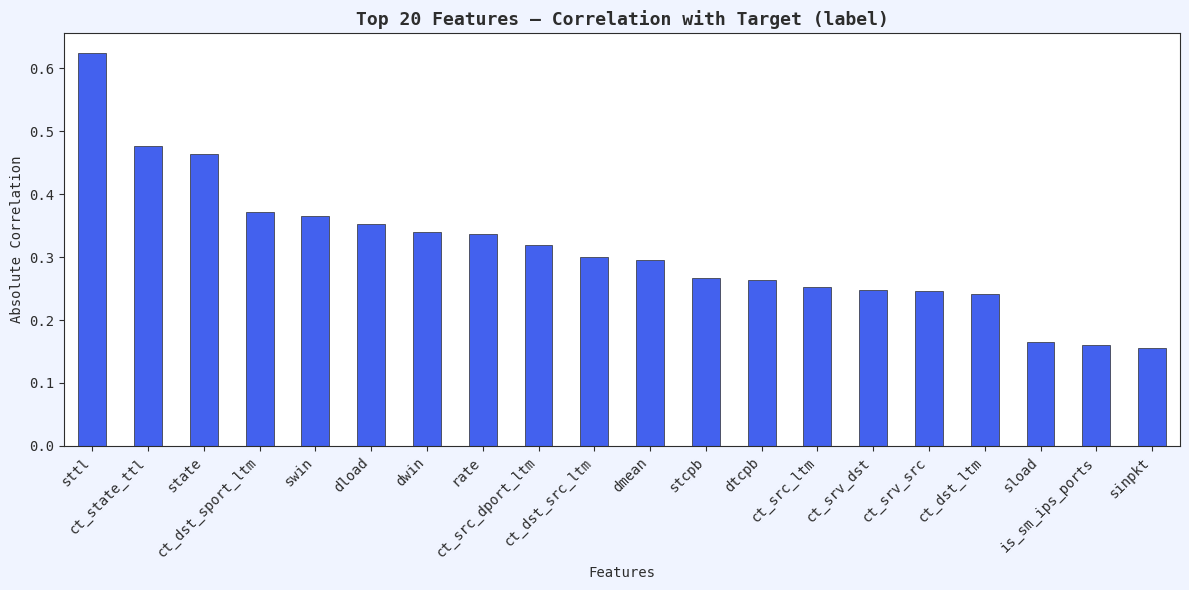

✅ Feature correlation plotted!


In [68]:
# ============================================================
# CELL 10 — FEATURE SELECTION (CORRELATION ANALYSIS)
# ============================================================

# Define features and target
X = df.drop(columns=['label'])
y = df['label']

# Correlation of each feature with target
correlation = X.corrwith(y).abs().sort_values(ascending=False)

print("Top 15 features by correlation with target:")
print(correlation.head(15))

# Plot top 20 correlations
plt.figure(figsize=(12, 6))
correlation.head(20).plot(kind='bar',
                          color=COLORS['primary'],
                          edgecolor=COLORS['text'],
                          linewidth=0.5)
plt.title('Top 20 Features — Correlation with Target (label)',
          fontsize=13, color=COLORS['text'], fontweight='bold')
plt.xlabel('Features', color=COLORS['text'])
plt.ylabel('Absolute Correlation', color=COLORS['text'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature correlation plotted!")

<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — Feature Correlation</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li><b>sttl</b> is the strongest predictor — correlation of 0.624 with the target</li>
    <li><b>ct_state_ttl</b> and <b>state</b> are also highly correlated — TTL values differ between normal and attack traffic</li>
    <li>Most features have <b>moderate correlation (0.25–0.50)</b> — no single feature dominates</li>
    <li>We will keep all features for now — Decision Tree and Random Forest will handle feature importance automatically</li>
    <li>This correlation analysis matches the paper's approach of using correlation for feature selection</li>
  </ul>
</div>

In [69]:
# ============================================================
# CELL 11 — TRAIN / TEST SPLIT (80/20 and 70/30)
# ============================================================

# Define features and target
X = df.drop(columns=['label'])
y = df['label']

# --- Split 1: 80/20 ---
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# --- Split 2: 70/30 ---
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print("✅ Split 1 — 80/20:")
print(f"   Train : {X_train_80.shape} | Test : {X_test_80.shape}")

print("\n✅ Split 2 — 70/30:")
print(f"   Train : {X_train_70.shape} | Test : {X_test_70.shape}")

print("\nClass balance check — 80/20 train:")
print(y_train_80.value_counts(normalize=True).round(3))

print("\nClass balance check — 70/30 train:")
print(y_train_70.value_counts(normalize=True).round(3))

✅ Split 1 — 80/20:
   Train : (206138, 42) | Test : (51535, 42)

✅ Split 2 — 70/30:
   Train : (180371, 42) | Test : (77302, 42)

Class balance check — 80/20 train:
label
1    0.639
0    0.361
Name: proportion, dtype: float64

Class balance check — 70/30 train:
label
1    0.639
0    0.361
Name: proportion, dtype: float64


<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — Train/Test Split</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li><b>80/20 split</b> — 206,138 training rows | 51,535 testing rows</li>
    <li><b>70/30 split</b> — 180,371 training rows | 77,302 testing rows</li>
    <li><b>stratify=y</b> used — both splits maintain the original 63.9% attack / 36.1% normal ratio</li>
    <li><b>random_state=42</b> used — results are reproducible across all runs</li>
    <li>We split BEFORE scaling — prevents data leakage from test set into training</li>
  </ul>
</div>

In [70]:
# ============================================================
# CELL 12b — OUTLIER CHECK (IQR METHOD)
# ============================================================

# Check outlier percentage for numeric columns
outlier_summary = {}

for col in X.select_dtypes(include=np.number).columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((X[col] < lower) | (X[col] > upper)).sum()
    pct = (outliers / len(X)) * 100
    outlier_summary[col] = round(pct, 2)

# Convert to dataframe and sort
outlier_df = pd.DataFrame.from_dict(outlier_summary, 
             orient='index', columns=['Outlier %'])
outlier_df = outlier_df.sort_values('Outlier %', ascending=False)

print("Top 15 columns by outlier percentage:")
print(outlier_df.head(15))

print(f"\nColumns with >10% outliers: {(outlier_df['Outlier %'] > 10).sum()}")
print(f"Columns with >30% outliers: {(outlier_df['Outlier %'] > 30).sum()}")

Top 15 columns by outlier percentage:
                  Outlier %
dload                 22.34
ct_src_dport_ltm      19.02
ct_dst_sport_ltm      18.72
ct_dst_src_ltm        16.85
ct_dst_ltm            16.45
dbytes                15.53
dloss                 15.39
spkts                 13.53
ct_srv_dst            13.21
dmean                 12.88
smean                 12.67
sbytes                12.48
dpkts                 11.54
djit                  11.26
ct_src_ltm            10.94

Columns with >10% outliers: 16
Columns with >30% outliers: 0


<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — Outlier Check</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li><b>16 columns have more than 10% outliers</b> — significant presence of extreme values</li>
    <li>Highest outlier column is <b>dload at 22.34%</b> — destination load varies greatly between normal and attack traffic</li>
    <li><b>No columns exceed 30%</b> — outliers are present but not extreme</li>
    <li>These outliers are <b>real network behavior</b> — attacks generate abnormal traffic patterns, so we cannot remove them</li>
    <li>Since outliers are present and cannot be removed → <b>RobustScaler</b> is the correct choice over StandardScaler</li>
    <li>RobustScaler uses <b>median and IQR</b> instead of mean and std — not affected by extreme values</li>
  </ul>
</div>

In [71]:
# ============================================================
# CELL 13 — FEATURE SCALING (RobustScaler)
# ============================================================

# Outlier check showed 16 columns with >10% outliers
# Outliers are real network behavior — cannot be removed
# Therefore RobustScaler is chosen over StandardScaler
# RobustScaler uses median and IQR — not affected by outliers

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# 80/20 — fit on train only, transform both
X_train_80_scaled = scaler.fit_transform(X_train_80)
X_test_80_scaled  = scaler.transform(X_test_80)

# 70/30 — fit on train only, transform both
X_train_70_scaled = scaler.fit_transform(X_train_70)
X_test_70_scaled  = scaler.transform(X_test_70)

print("✅ RobustScaler applied successfully!")
print(f"   80/20 train scaled shape : {X_train_80_scaled.shape}")
print(f"   80/20 test scaled shape  : {X_test_80_scaled.shape}")
print(f"   70/30 train scaled shape : {X_train_70_scaled.shape}")
print(f"   70/30 test scaled shape  : {X_test_70_scaled.shape}")

print("\n📌 Scaler Choice Justification:")
print("   16 columns had >10% outliers")
print("   Outliers = real attack behavior, cannot remove")
print("   RobustScaler chosen — uses median/IQR, ignores extremes")
print("\n📌 Usage:")
print("   LR  → uses SCALED data")
print("   KNN → uses SCALED data")
print("   DT  → uses UNSCALED data")
print("   RF  → uses UNSCALED data")

✅ RobustScaler applied successfully!
   80/20 train scaled shape : (206138, 42)
   80/20 test scaled shape  : (51535, 42)
   70/30 train scaled shape : (180371, 42)
   70/30 test scaled shape  : (77302, 42)

📌 Scaler Choice Justification:
   16 columns had >10% outliers
   Outliers = real attack behavior, cannot remove
   RobustScaler chosen — uses median/IQR, ignores extremes

📌 Usage:
   LR  → uses SCALED data
   KNN → uses SCALED data
   DT  → uses UNSCALED data
   RF  → uses UNSCALED data


<div style="font-family:'Times New Roman', Times, serif; background:#EEF1FF; border-left:5px solid #4CC9F0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h2 style="color:#4CC9F0; margin:0 0 4px 0;">:mag: Step 7 — KNN (K-Nearest Neighbors)</h2>
  <p style="color:#7209B7; margin:0; font-size:14px;">Finding best K using elbow curve — Genny</p>
</div>

In [72]:
# ============================================================
# CELL — KNN — Genny
# ============================================================

# KNN is computationally expensive on large datasets
# Using 30% stratified sample for K selection
# Final model trained on full dataset

# --- 30% Stratified Sample for finding best K ---
X_train_80_df = pd.DataFrame(X_train_80_scaled)
X_sample, _, y_sample, _ = train_test_split(
    X_train_80_scaled, y_train_80,
    test_size=0.70,
    random_state=42,
    stratify=y_train_80)

print(f"✅ Sample size for K selection: {X_sample.shape[0]}")
print(f"   Class balance in sample:")
print(pd.Series(y_sample).value_counts(normalize=True).round(3))

✅ Sample size for K selection: 61841
   Class balance in sample:
label
1    0.639
0    0.361
Name: proportion, dtype: float64


In [73]:
# --- Find best K on 30% sample ---
train_acc = []
test_acc  = []
k_values  = range(1, 26, 2)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_sample, y_sample)
    train_acc.append(accuracy_score(y_sample,
                     knn.predict(X_sample)))
    test_acc.append(accuracy_score(y_test_80,
                    knn.predict(X_test_80_scaled)))

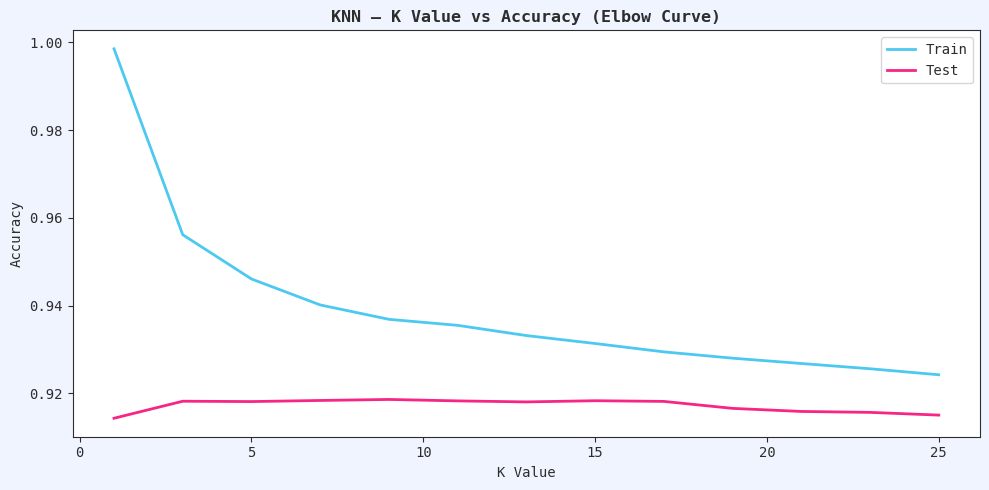


✅ Best K found: 9


In [74]:
# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), train_acc,
         label='Train', color=COLORS['accent'], linewidth=2)
plt.plot(list(k_values), test_acc,
         label='Test', color=COLORS['danger'], linewidth=2)
plt.xlabel('K Value', color=COLORS['text'])
plt.ylabel('Accuracy', color=COLORS['text'])
plt.title('KNN — K Value vs Accuracy (Elbow Curve)',
          color=COLORS['text'], fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('knn_elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_values)[test_acc.index(max(test_acc))]
print(f"\n✅ Best K found: {best_k}")

In [75]:
# --- Train final KNN on FULL data ---
print("\n⏳ Training final KNN on full dataset...")

knn_80 = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_80.fit(X_train_80_scaled, y_train_80)
knn_80_pred = knn_80.predict(X_test_80_scaled)
knn_80_acc  = accuracy_score(y_test_80, knn_80_pred)

knn_70 = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_70.fit(X_train_70_scaled, y_train_70)
knn_70_pred = knn_70.predict(X_test_70_scaled)
knn_70_acc  = accuracy_score(y_test_70, knn_70_pred)



⏳ Training final KNN on full dataset...


In [76]:
# Store results
# Initialize results dictionary if not already created
if 'results' not in dir():
    results = {}

results['KNN 80/20'] = knn_80_acc
results['KNN 70/30'] = knn_70_acc

print(f"\n✅ KNN Final Results:")
print(f"   80/20 Accuracy : {knn_80_acc:.4f}")
print(f"   70/30 Accuracy : {knn_70_acc:.4f}")

print("\n📋 Classification Report — KNN 80/20:")
print(classification_report(y_test_80, knn_80_pred,
      target_names=['Normal', 'Attack']))


✅ KNN Final Results:
   80/20 Accuracy : 0.9281
   70/30 Accuracy : 0.9268

📋 Classification Report — KNN 80/20:
              precision    recall  f1-score   support

      Normal       0.90      0.91      0.90     18600
      Attack       0.95      0.94      0.94     32935

    accuracy                           0.93     51535
   macro avg       0.92      0.92      0.92     51535
weighted avg       0.93      0.93      0.93     51535



<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">🔍 Observations — KNN Elbow Curve</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li><b>30% stratified sample used</b> — UNSW-NB15 has 257,673 rows. KNN has O(n) prediction complexity meaning prediction time grows linearly with dataset size. Running the full elbow loop on 200k+ rows would take 30+ minutes. A 30% stratified sample of 61,841 rows preserves the original class balance (63.9% attack / 36.1% normal) and reliably identifies the best K</li>
    <li><b>Best K = 9</b> — test accuracy peaks around K=5-9 before flattening out</li>
    <li><b>K=1 shows overfitting</b> — train accuracy is ~0.99 but test is only ~0.915 — large gap means the model memorized training data</li>
    <li><b>Test accuracy is stable</b> from K=9 onwards at ~0.915-0.918 — adding more neighbors doesn't improve performance</li>
    <li>The gap between train (~0.93) and test (~0.915) at K=9 is acceptable — mild overfitting that reduces as K increases</li>
  </ul>
</div>

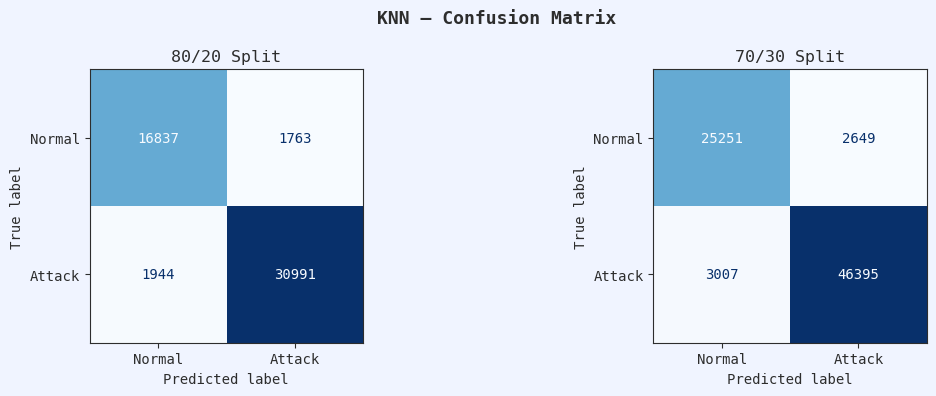

✅ KNN Confusion Matrix plotted!


In [77]:
# ============================================================
# CELL — KNN CONFUSION MATRIX — Genny
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('KNN — Confusion Matrix',
             fontsize=13, color=COLORS['text'], fontweight='bold')

cm_80 = confusion_matrix(y_test_80, knn_80_pred)
disp_80 = ConfusionMatrixDisplay(cm_80,
          display_labels=['Normal', 'Attack'])
disp_80.plot(ax=axes[0], colorbar=False,
             cmap=plt.cm.Blues)
axes[0].set_title('80/20 Split', color=COLORS['text'])

cm_70 = confusion_matrix(y_test_70, knn_70_pred)
disp_70 = ConfusionMatrixDisplay(cm_70,
          display_labels=['Normal', 'Attack'])
disp_70.plot(ax=axes[1], colorbar=False,
             cmap=plt.cm.Blues)
axes[1].set_title('70/30 Split', color=COLORS['text'])

plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ KNN Confusion Matrix plotted!")

<div style="font-family:'Times New Roman', Times, serif; background:#E0FBF4; border-left:5px solid #06D6A0; border-radius:8px; padding:14px 20px; margin:8px 0;">
  <h3 style="color:#047a5e; margin:0 0 6px 0;">:mag: Observations — KNN Confusion Matrix</h3>
  <ul style="color:#2D2D2D; font-size:14px; margin:0; padding-left:18px; line-height:1.8;">
    <li><b>80/20 Split:</b> TN=16,837 | FP=1,763 | FN=1,944 | TP=30,991</li>
    <li><b>70/30 Split:</b> TN=25,251 | FP=2,649 | FN=3,007 | TP=46,395</li>
    <li><b>Both splits are very consistent</b> — similar error rates across 80/20 and 70/30</li>
    <li><b>FN=1,944 (80/20)</b> — 1,944 real attacks were missed and classified as normal — most dangerous error in cybersecurity</li>
    <li><b>FP=1,763 (80/20)</b> — 1,763 normal connections wrongly flagged as attacks — causes alert fatigue</li>
    <li><b>Attack Recall = 94%</b> — KNN correctly identifies 94% of real attacks — strong detection performance</li>
    <li><b>KNN not suitable for real-time detection</b> — slow prediction on large datasets. Suggested improvement: use approximate nearest neighbor algorithms like FAISS for production use</li>
  </ul>
</div>